# Surface-Frame Stiffness Analysis (flat-surface-follow)

Interprets the **impedance stiffness** the policy applies while tracking a flat
surface, resolved onto the **surface frame** — the phaseless, surface-following
analogue of `stiff_rot_analysis` (which splits a peg insertion by task phase).

The flat-surface-follow task has **no phases** (`free_space` -> `search` ->
`insertion`): the tool is in contact tracking the surface for the whole episode, so
every metric is a single end-of-training value. The natural reference frame is the
**surface frame** `[along-track, cross-track, normal]`, not the peg axis. The applied
translational stiffness `K` resolved onto those axes is logged by
`wrappers/controllers/ctrl_action_interface.py::_log_stiffness_frame_metrics` as
`diag(R_surfᵀ K R_surf)`:

* **k_normal** (k$_n$) — stiffness along the surface **normal** (the vertical
  into-surface axis); how hard the policy presses down / resists penetration.
* **k_along_track** (k$_\parallel$) — stiffness **along** the path direction.
* **k_cross_track** (k$_\perp$) — in-plane **lateral** stiffness (across the path).

An isotropic baseline (Fixed) reads ~equal in all three; the rotated / GAS modes
shape the three directions differently.

**Ovals:** the stiffness-oval cartoon is inherently 2-D, so each oval shows only two
directions — the **normal (vertical axis)** and **along-track (horizontal)** — with
cross-track dropped. Round = isotropic, tall = stiff-normal / compliant-along.

Loading lives in `data_loader.py`; plotting in `plot_tools.py`. This notebook only
sets parameters and renders outputs.


## 1. Imports

In [1]:
import os
import sys
from datetime import datetime

import numpy as np
import matplotlib.pyplot as plt


# The utility modules (data_loader.py, plot_tools.py) live next to this notebook
# in data_analysis/. Make them importable whether the kernel starts in
# data_analysis/ or the repo root by walking up from the cwd to find them.
def _ensure_on_path():
    d = os.path.abspath(os.getcwd())
    while True:
        for cand in (os.path.join(d, "data_analysis"), d):
            if os.path.isfile(os.path.join(cand, "data_loader.py")):
                if cand not in sys.path:
                    sys.path.insert(0, cand)
                return
        parent = os.path.dirname(d)
        if parent == d:
            return
        d = parent


_ensure_on_path()
import importlib
import data_loader as dl   # data loading + reduction (single source of truth)
import plot_tools as pt    # plotting + styling (single source of truth)

# Force a fresh load from disk every time this cell runs, so edits to data_loader.py /
# plot_tools.py (display names, colors, loaders) take effect WITHOUT restarting the kernel.
# Reload data_loader FIRST — plot_tools imports it, so it must re-bind the updated module.
importlib.reload(dl)
importlib.reload(pt)

<module 'plot_tools' from '/home/hunter/generalized_hybrid_vic_action_space/data_analysis/plot_tools.py'>

## 2. Global parameters

Folder, surface-direction specs, reduction, output folder, and the shared `STYLE` object.

In [2]:
# Root folder that contains the experiment-group sub-folders (runs/{FOLDER_NAME}).
PROJECT_ROOT = dl.find_project_root()
RUNS_ROOT = dl.runs_root()
# --- Data source. Set WANDB_PROJECT + WANDB_TAG to pull runs from Weights & Biases:
# downloaded ONCE into runs/{WANDB_PROJECT}_{WANDB_TAG}/ (cached — the load cell below skips
# groups already present, so this notebook AND the other surface notebooks reuse the same data).
# Set WANDB_PROJECT/WANDB_TAG = None to load a local LOCAL_FOLDER instead.
WANDB_PROJECT = "surface_baselines"
WANDB_TAG     = "fixed-types_loss_v1"
WANDB_ENTITY  = "hur"
LOCAL_FOLDER  = "baseline_swap"  # used only when WANDB_PROJECT/TAG are None
FOLDER_NAME   = f"{WANDB_PROJECT}_{WANDB_TAG}" if (WANDB_PROJECT and WANDB_TAG) else LOCAL_FOLDER

# Confidence band: mean +/- CI_Z * SEM across runs. 1.96 -> ~95% CI.
CI_Z = 1.96

# Keep only the top-N runs per group (ranked by peak success); -1 keeps all.
TOP_N = -1
SUCCESS_METRIC = "Episode / Ever success rate"

# Shared x-axis for time-series plots. XLIM is (min, max) or None.
XLABEL = "Env Steps"
XLIM = (0, 81001)

# The flat-surface-follow task has NO free_space -> search -> insertion phases (the
# tool tracks a surface the whole episode), so there is nothing to split on — unlike
# the peg notebook, every metric here is a single end-of-training value. The natural
# reference frame is the SURFACE frame [along-track, cross-track, normal] rather than
# the peg axis; the applied stiffness resolved onto those axes is logged as
# Impedance_Stiffness/k_{along_track,cross_track,normal}_mean (see
# ctrl_action_interface._log_stiffness_frame_metrics). NORMAL is the vertical
# into-surface axis; ALONG-TRACK follows the path; CROSS-TRACK is the in-plane lateral.
SURF = pt.SURFACE_STIFFNESS_TAGS   # {"along_track","cross_track","normal"} -> tag
DIR_SPECS = [
    {"key": "normal",      "tag": SURF["normal"],      "label": "k$_n$ (normal / into-surface)"},
    {"key": "along_track", "tag": SURF["along_track"], "label": "k$_\\parallel$ (along-track)"},
    {"key": "cross_track", "tag": SURF["cross_track"], "label": "k$_\\perp$ (cross-track)"},
]

# How each scalar is reduced per run before aggregating across runs.
# "mean_tail" averages the last few logged points (denoises the converged value);
# alternatives: "last", "at_best" (value at the run's peak-success step), "max".
REDUCE = "mean_tail"

# Dated output folder: runs/{FOLDER_NAME}/plots_stiffsurf_{date}/{name}.svg
PLOTS_DIR = os.path.join(RUNS_ROOT, FOLDER_NAME,
                         f"plots_stiffsurf_{datetime.now().strftime('%Y%m%d')}")

# Styling/context. Display names + colors default to the surface controller ladder
# (Fixed / VICES / GAS variants); see plot_tools.PlotStyle.
STYLE = pt.PlotStyle(ci_z=CI_Z, xlabel=XLABEL, xlim=XLIM, plots_dir=PLOTS_DIR)
STEP_CEILING = STYLE.step_ceiling

## 3. Load data

In [3]:
# Pull from wandb into runs/{FOLDER_NAME}/ (download once; cached). No-op for a local FOLDER_NAME.
if WANDB_PROJECT and WANDB_TAG:
    dl.download_wandb_data(WANDB_PROJECT, WANDB_TAG, entity=WANDB_ENTITY, root=RUNS_ROOT)
DATA = dl.load_data(FOLDER_NAME, RUNS_ROOT)
DATA = dl.filter_top_n(DATA, TOP_N, SUCCESS_METRIC, STEP_CEILING)

# Confirm the surface-frame stiffness family is present in the loaded runs.
_tags = sorted({t for run in next(iter(DATA.values())) for t in run})
print("surface-frame stiffness tags:",
      [t for t in _tags if "Impedance_Stiffness/k_" in t and t.endswith("_mean")])

wandb: [wandb.Api()] Loaded credentials for https://api.wandb.ai from /home/hunter/.netrc.


[wandb-dl] 21 run(s) in hur/surface_baselines tagged 'fixed-types_loss_v1' -> 7 group(s) -> /home/hunter/generalized_hybrid_vic_action_space/runs/surface_baselines_fixed-types_loss_v1
[wandb-dl]   1_fixed: cached (3 runs), skip
[wandb-dl]   2_VICES: cached (3 runs), skip
[wandb-dl]   4_GAS_fixed_rot: cached (3 runs), skip
[wandb-dl]   5_GAS: cached (3 runs), skip
[wandb-dl]   6_dynm_fixed_rot: cached (3 runs), skip
[wandb-dl]   7_GAS_dyn: cached (3 runs), skip
[wandb-dl]   8_GAS_geo: cached (3 runs), skip


I0000 00:00:1784650490.987750 4114373 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1784650491.018591 4114373 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI AVX_VNNI_INT8 AVX_NE_CONVERT FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1784650491.849929 4114373 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


1_fixed: 3 runs loaded
2_VICES: 3 runs loaded
4_GAS_fixed_rot: 3 runs loaded
5_GAS: 3 runs loaded
6_dynm_fixed_rot: 3 runs loaded
7_GAS_dyn: 3 runs loaded
8_GAS_geo: 3 runs loaded
surface-frame stiffness tags: ['Impedance_Stiffness/k_along_track_mean', 'Impedance_Stiffness/k_cross_track_mean', 'Impedance_Stiffness/k_normal_mean']


## 4. Directional stiffness table

End-of-training surface-frame stiffness per controller (normal / along-track / cross-track).

In [4]:
# End-of-training surface-frame stiffness table. For each controller, the applied
# translational stiffness resolved onto the three SURFACE directions (normal /
# along-track / cross-track), reduced with REDUCE, mean +/- 95% CI across runs.
# These are descriptive (how the policy shapes its compliance), not better/worse,
# so nothing is bolded. An isotropic baseline (Fixed) reads ~equal in all three.
print(f"Surface-frame stiffness by direction (reduce={REDUCE})\n")
hdr = ["controller"] + [s["label"].replace("$", "").replace("\\", "") for s in DIR_SPECS]
print("  ".join(f"{h:>28}" for h in hdr))
summaries = {s["key"]: dl.summarize_tag(DATA, s["tag"], reduce=REDUCE, ci_z=CI_Z,
                                        step_ceiling=STEP_CEILING) for s in DIR_SPECS}
for group in DATA:
    cells = [STYLE.name(group)]
    for s in DIR_SPECS:
        st = summaries[s["key"]]
        cells.append(f"{st[group][0]:.1f} +/- {st[group][1]:.1f}" if group in st else "--")
    print("  ".join(f"{c:>28}" for c in cells))

Surface-frame stiffness by direction (reduce=mean_tail)

                  controller   k_n (normal / into-surface)      k_parallel (along-track)          k_perp (cross-track)
                       Fixed                 565.0 +/- 0.0                 565.0 +/- 0.0                 565.0 +/- 0.0
                       VICES                 725.3 +/- 0.7                 628.4 +/- 4.5                 601.3 +/- 1.7
           Ours (GT Geo-Rot)                 720.6 +/- 5.2                 660.7 +/- 4.9                 562.3 +/- 3.0
            Ours (No-Losses)                 711.5 +/- 5.7                 711.4 +/- 5.7                 711.4 +/- 5.9
           Ours (GT Dyn-Rot)                 639.2 +/- 2.9                 648.5 +/- 2.2                 594.7 +/- 7.2
             Ours (Dyn-Loss)                657.0 +/- 11.0                671.7 +/- 12.4                628.7 +/- 13.0
             Ours (Geo-Loss)                689.5 +/- 11.0                677.3 +/- 15.6                 606.2

## 5. Directional stiffness over training

One facet per surface direction; the main diagnostic for *when* each direction is shaped.

saved /home/hunter/generalized_hybrid_vic_action_space/runs/surface_baselines_fixed-types_loss_v1/plots_stiffsurf_20260721/surface_stiffness_by_direction.svg


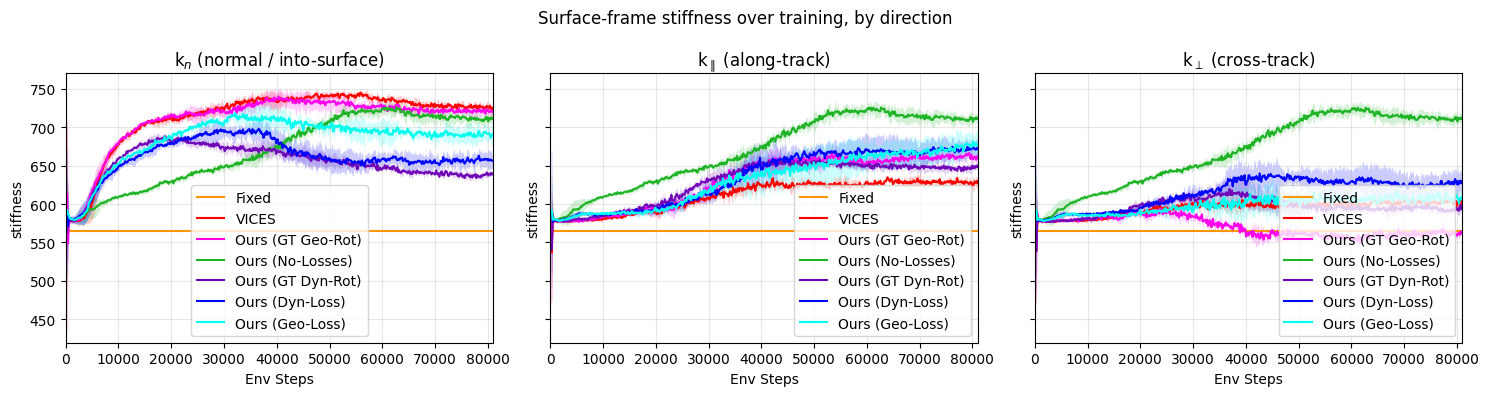

In [5]:
# (1) Directional stiffness over training — one facet per surface direction
# (normal / along-track / cross-track). Answers "did the policy LEARN to shape its
# compliance per direction, and when in training?". One mean+CI line per controller.
fig, axes = plt.subplots(1, len(DIR_SPECS), figsize=(5 * len(DIR_SPECS), 4), sharey=True)
for ax, s in zip(axes, DIR_SPECS):
    pt.plot_metric(DATA, s["tag"], "stiffness", s["label"], STYLE, ax=ax,
                   legend_loc="best")
    ax.set_title(s["label"])
fig.suptitle("Surface-frame stiffness over training, by direction")
fig.tight_layout()
pt.save_plot(fig, "surface_stiffness_by_direction", STYLE)
plt.show()

## 6. k$_n$ vs k$_\parallel$ scatter

saved /home/hunter/generalized_hybrid_vic_action_space/runs/surface_baselines_fixed-types_loss_v1/plots_stiffsurf_20260721/surface_normal_vs_along.svg


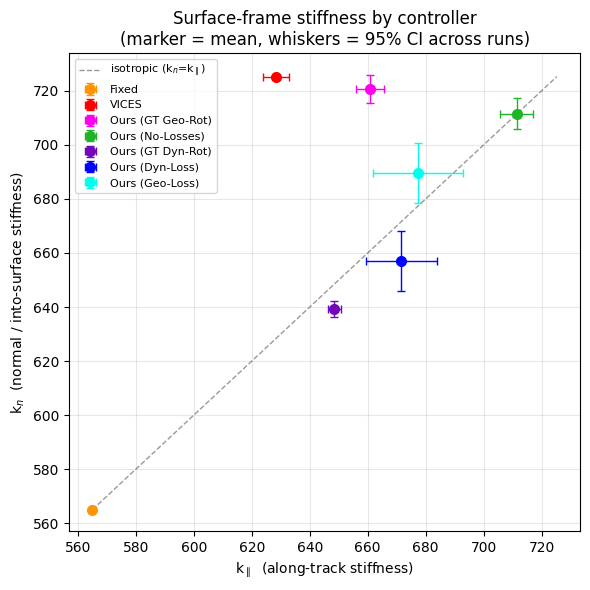

In [6]:
# (2) k_normal vs k_along_track scatter — one marker (mean +/- 95% CI) per
# controller, reduced end-of-training. The y = x line is isotropy: ABOVE it the
# policy presses harder INTO the surface than it resists ALONG the path (typical
# surface-following compliance), BELOW it the reverse. Cross-track is omitted here
# so the plane reads as normal-vs-tangent; see the table/curves for cross-track.
ax = pt.plot_surface_stiffness_scatter(DATA, STYLE, reduce=REDUCE)
ax.figure.tight_layout()
pt.save_plot(ax.figure, "surface_normal_vs_along", STYLE)
plt.show()

## 7. Stiffness-oval cartoon (normal vs along-track)

saved /home/hunter/generalized_hybrid_vic_action_space/runs/surface_baselines_fixed-types_loss_v1/plots_stiffsurf_20260721/surface_stiffness_ovals.svg


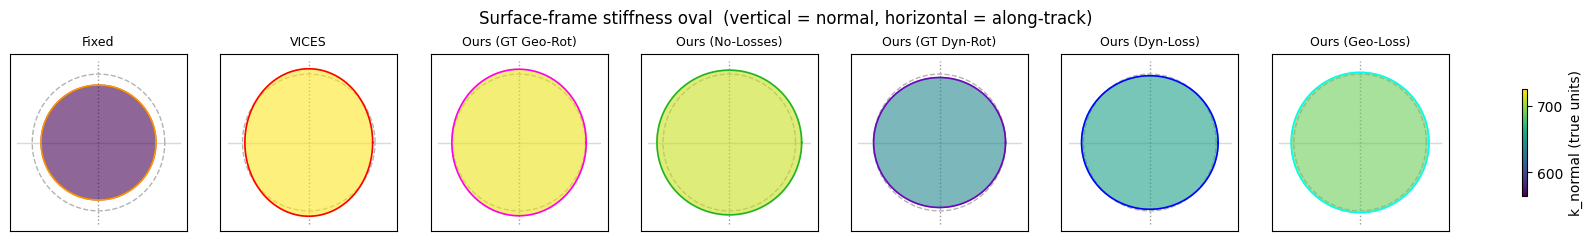

In [7]:
# (3) Stiffness-oval cartoon, one panel per controller. Each oval shows only TWO of
# the three surface directions — the surface NORMAL on the vertical axis (semi-axis =
# k_normal) and ALONG-TRACK horizontally (semi-axis = k_along_track); cross-track is
# dropped so the shape is a clean profile of "press-down vs. resist-along". The
# surface frame is orthonormal, so the ovals are upright (no tilt term is logged,
# unlike the peg-axis version). Round = isotropic; tall = stiff-normal / compliant-
# along; wide = the reverse.
#   COLOR_BY_NORMAL -> fill each oval by its TRUE k_normal via a shared colorbar.
#   SHOW_GHOST      -> draw the grand-mean oval (dashed grey) in every panel as a
#                      fixed anchor; each oval's deviation from it is the signal.
COLOR_BY_NORMAL = True
SHOW_GHOST = True
fig = pt.plot_surface_stiffness_ellipses(DATA, STYLE, reduce=REDUCE,
                                         color_by_normal=COLOR_BY_NORMAL, ghost=SHOW_GHOST)
pt.save_plot(fig, "surface_stiffness_ovals", STYLE)
plt.show()

saved /home/hunter/generalized_hybrid_vic_action_space/runs/surface_baselines_fixed-types_loss_v1/plots_stiffsurf_20260721/surface_stiffness_ovals_stretched.svg


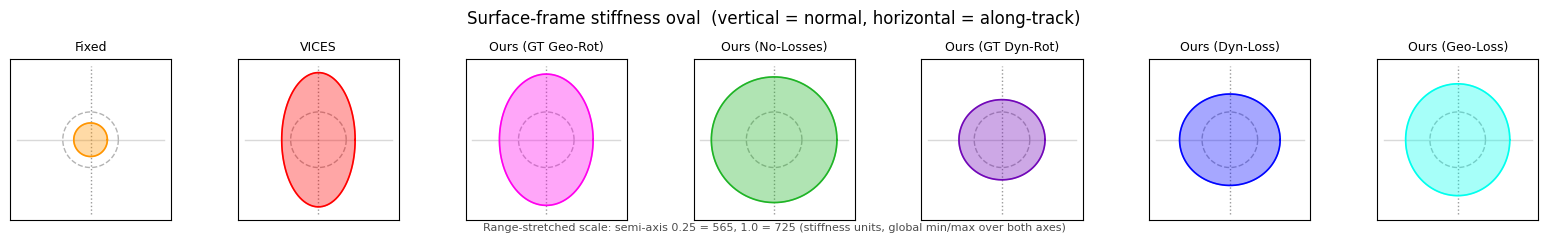

In [8]:
# (3a) Same ovals, range-stretched scale so small differences pop. Instead of
# dividing both semi-axes by the global MAX (which leaves every oval near full height
# when the directional stiffnesses only span a narrow band), scale_mode="range"
# affine-maps the global [min, max] over ALL semi-axis values (normal AND along-track
# pooled) onto [0.25, 1.0]. Same transform on both axes, so it stays relatively
# geometric while stretching the dynamic range. (Magnitudes are exaggerated; read
# shape/trend, not absolute size.) GHOST_NORMAL sets the reference oval radius in TRUE
# stiffness units, run through the same range map so it reads on the same scale.
SHOW_GHOST = True
GHOST_NORMAL = 600.0   # reference stiffness (true units); set to your anchor of choice
fig = pt.plot_surface_stiffness_ellipses(DATA, STYLE, reduce=REDUCE,
                                         scale_mode="range", ghost=SHOW_GHOST,
                                         ghost_normal=GHOST_NORMAL)
pt.save_plot(fig, "surface_stiffness_ovals_stretched", STYLE)
plt.show()